In [2]:
# Library
import pandas as pd
import os
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data Collection

In [3]:
df = pd.read_csv('datasets/dataset_spotify_tracks.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Preprocessing Data

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Missing Value

In [5]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [6]:
df = df.dropna()
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## Data Duplicate

In [7]:
print("Jumlah duplikat identik:", df.duplicated().sum())

Jumlah duplikat identik: 0


## Normalize Data

In [8]:
df_clean = df.copy()

df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_clean = df_clean.drop(columns=["unnamed:_0"], errors="ignore")

text_cols = ["track_id", "artists", "album_name", "track_name", "track_genre"]

for col in text_cols:
    df_clean[col] = df_clean[col].astype("string").str.strip()

df_clean["explicit"] = df_clean["explicit"].astype(bool)
df_clean["track_genre"] = df_clean["track_genre"].astype("category")

df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   track_id          113999 non-null  string  
 1   artists           113999 non-null  string  
 2   album_name        113999 non-null  string  
 3   track_name        113999 non-null  string  
 4   popularity        113999 non-null  int64   
 5   duration_ms       113999 non-null  int64   
 6   explicit          113999 non-null  bool    
 7   danceability      113999 non-null  float64 
 8   energy            113999 non-null  float64 
 9   key               113999 non-null  int64   
 10  loudness          113999 non-null  float64 
 11  mode              113999 non-null  int64   
 12  speechiness       113999 non-null  float64 
 13  acousticness      113999 non-null  float64 
 14  instrumentalness  113999 non-null  float64 
 15  liveness          113999 non-null  float64 
 16  valence

# EDA

## Customer Side

### Is audio features (energy, danceability, valence, tempo) are most strongly correlated with a song’s popularity?

popularity          1.000000
loudness            0.050420
explicit            0.044078
danceability        0.035444
time_signature      0.031076
tempo               0.013212
energy              0.001053
key                -0.003847
liveness           -0.005397
duration_ms        -0.007129
mode               -0.013948
acousticness       -0.025458
valence            -0.040522
speechiness        -0.044930
instrumentalness   -0.095147
Name: popularity, dtype: float64

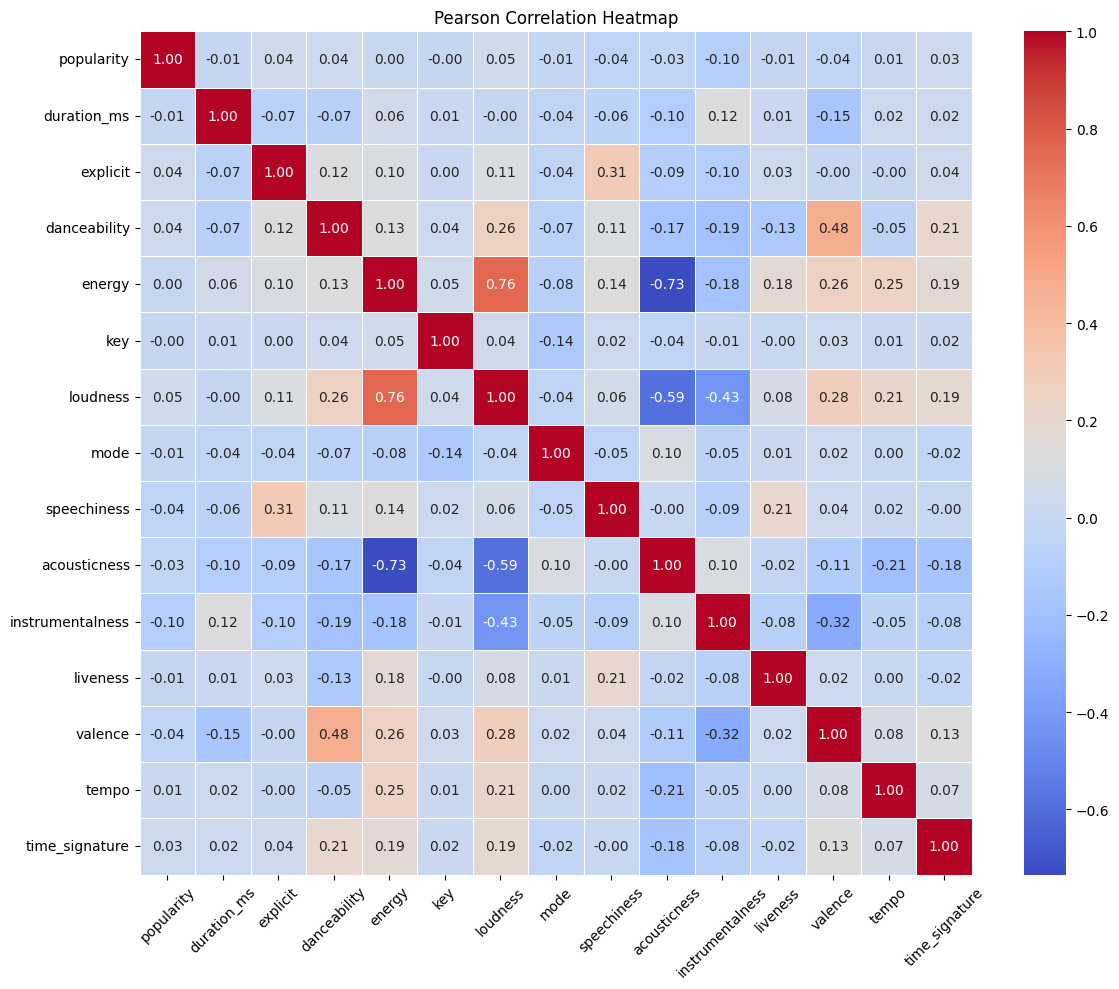

In [9]:
numeric_df = df_clean.select_dtypes(include=["number", "bool"])

correlation_matrix = numeric_df.corr(method="pearson")

popularity_corr = correlation_matrix["popularity"].sort_values(ascending=False)
display(popularity_corr)

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Insight:

Semua korelasi dengan popularitas sangat rendah. Ini sendiri adalah temuan penting:
popularitas lagu tidak bisa diprediksi hanya dari fitur audio-nya.
Yang lebih menarik adalah korelasi antar fitur:

- energy ↔ loudness: +0.76 (sangat kuat) — lagu keras = lagu berenergi
- energy ↔ acousticness: -0.73 (sangat kuat negatif) — lagu akustik cenderung tenang
- danceability ↔ valence: +0.48 — lagu yang enak digerakin cenderung terasa positif/happy

Interpretasi bisnis:
Lagu populer di Spotify cenderung memiliki **profil audio: energy tinggi + loudness tinggi

- acousticness rendah** — identik dengan karakteristik pop dan hip-hop mainstream.
Ini bukan "formula ajaib", tapi preferensi mayoritas pendengar streaming global.

### Are shorter songs more popular in the streaming era?

In [10]:
df_clean["duration_min"] = df_clean["duration_ms"] / 60000

sample_df = df_clean.sample(5000, random_state=42)

fig = px.scatter(
    sample_df,
    x="duration_min",
    y="popularity",
    hover_data=["track_name", "artists", "track_genre"],
    trendline="ols",
    title="Does Shorter Song Duration Relate to Higher Popularity?",
    labels={
        "duration_min": "Duration (minutes)",
        "popularity": "Popularity"
    },
    opacity=0.4
)

fig.show()

Insight:

Mayoritas lagu dengan popularitas tinggi berada di rentang durasi 2–5 menit.
Di atas 8 menit, popularitas menurun drastis. Trendline keseluruhan hampir flat
(korelasi sangat lemah: r ≈ -0.01), namun distribusi datanya bercerita lain.

Interpretasi bisnis:

Di era streaming dan short-form content, pendengar cepat berpindah lagu.
Durasi optimal 3–4 menit memberi ruang untuk hook, verse, chorus, dan bridge
tanpa kehilangan perhatian pendengar.

### Do songs with explicit lyrics have different levels of popularity compared to those without?

In [11]:
fig = px.box(
    df_clean,
    x="explicit",
    y="popularity",
    color="explicit",
    title="Popularity Distribution: Explicit vs Non-Explicit Songs",
    labels={
        "explicit": "Explicit Lyrics",
        "popularity": "Popularity"
    }
)

fig.show()

Insight:

Lagu explicit memiliki median popularitas sedikit lebih tinggi (37 vs 34),
namun dengan sebaran yang lebih lebar. Ini menunjukkan pola "boom or bust" yang berarti
lagu explicit berpotensi lebih viral, tapi juga lebih banyak yang tenggelam.

Interpretasi bisnis:

Konten eksplisit bukan jaminan sukses, tapi genre yang dominan menggunakannya
(hip-hop, rap) memang cenderung mendominasi chart streaming global.

## Artist Side

### Do artists with the largest catalog of songs automatically have a higher average level of popularity?

In [12]:
artist_summary = df.groupby("artists").agg(
    total_tracks=("track_id", "count"),
    avg_popularity=("popularity", "mean"),
    median_popularity=("popularity", "median")
).reset_index()

artist_summary = artist_summary.sort_values("total_tracks", ascending=False)

fig = px.scatter(
    artist_summary,
    x="total_tracks",
    y="avg_popularity",
    hover_data=["artists", "median_popularity"],
    title="Do Artists with Larger Catalogs Have Higher Average Popularity?",
    labels={
        "total_tracks": "Total Tracks",
        "avg_popularity": "Average Popularity"
    }
)

fig.show()

Insight:

Scatter plot menunjukkan pola terbalik yang jelas: artis dengan katalog sangat besar
(100+ lagu) justru cenderung punya rata-rata popularitas yang lebih rendah.
Popularitas tertinggi (80–100) hampir seluruhnya dimiliki artis dengan kurang dari 50 tracks.

The Beatles adalah outlier menarik, 279 tracks dengan avg popularity 61,
membuktikan bahwa legacy catalog bisa tetap relevan di platform streaming modern.

Interpretasi bisnis:

Di era streaming, kualitas dan relevansi lebih penting dari kuantitas.
Artis baru yang fokus merilis sedikit lagu berkualitas tinggi bisa melampaui
popularitas artis senior dengan ratusan katalog yang tidak semuanya relevan.

### Are artists who stick to a single genre more popular than those who experiment across genres?

In [16]:
artist_genre_summary = df_clean.groupby("artists").agg(
    total_tracks=("track_id", "count"),
    genre_count=("track_genre", "nunique"),
    avg_popularity=("popularity", "mean"),
    median_popularity=("popularity", "median")
).reset_index()

artist_genre_summary["artist_type"] = artist_genre_summary["genre_count"].apply(
    lambda x: "Single Genre" if x == 1 else "Multi Genre"
)

artist_genre_summary.groupby("artist_type").agg(
    artist_count=("artists", "count"),
    avg_popularity=("avg_popularity", "mean"),
    median_popularity=("avg_popularity", "median"),
    avg_total_tracks=("total_tracks", "mean")
)

,artist_count,avg_popularity,median_popularity,avg_total_tracks
artist_type,,,,
Multi Genre,6825,41.055548,44.0,7.945934
Single Genre,24612,35.258496,35.0,2.428409


In [18]:
fig = px.scatter(
    artist_genre_summary,
    x="genre_count",
    y="avg_popularity",
    size="total_tracks",
    hover_data=["artists", "total_tracks"],
    title="Does Genre Diversity Relate to Artist Popularity?",
    labels={
        "genre_count": "Number of Genres",
        "avg_popularity": "Average Popularity"
    }
)

fig.show()

Insight:

Artis multi-genre rata-rata lebih populer (~6 poin lebih tinggi) dan memiliki
katalog yang lebih besar. Dari bubble chart, artis dengan 3–5 genre
menunjukkan kluster popularitas tertinggi secara konsisten.

Namun, artis single genre yang sukses bisa mencapai popularitas sangat tinggi dan
distribusinya sangat lebar, artinya niche yang kuat juga bisa menjadi strategi efektif.

Interpretasi bisnis:

Diversifikasi genre membantu menjangkau lebih banyak segmen pendengar dan
algoritma Spotify. Tapi artis dengan identitas genre yang sangat kuat (niche)
tetap bisa viral, terutama jika genre tersebut sedang trending.

## Platform Side

### Which genres dominate Spotify, and how is their popularity distributed?

In [24]:
genre_counts = df_clean["track_genre"].value_counts().reset_index()
genre_counts.columns = ["track_genre", "total_tracks"]

top_genres = genre_counts.head(20)

top_genre_names = top_genres["track_genre"]

df_top_genres = df_clean[df_clean["track_genre"].isin(top_genre_names)]

fig = px.box(
    df_top_genres,
    x="track_genre",
    y="popularity",
    color="track_genre",
    title="Popularity Distribution Across Top Genres",
    labels={
        "track_genre": "Genre",
        "popularity": "Popularity"
    }
)

fig.show()


In [22]:
genre_popularity_summary = df_clean.groupby("track_genre").agg(
    total_tracks=("track_id", "count"),
    avg_popularity=("popularity", "mean"),
    median_popularity=("popularity", "median"),
    min_popularity=("popularity", "min"),
    max_popularity=("popularity", "max")
).reset_index()

genre_popularity_summary.sort_values("total_tracks", ascending=False).head(20)

C:\Users\Haikal Firdaus\AppData\Local\Temp\ipykernel_24504\539380462.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_popularity_summary = df_clean.groupby("track_genre").agg(


,track_genre,total_tracks,avg_popularity,median_popularity,min_popularity,max_popularity
0,acoustic,1000,42.483,47.0,0,82
1,afrobeat,1000,24.399,21.0,0,75
2,alt-rock,1000,33.943,45.0,0,93
3,alternative,1000,24.337,1.0,0,93
4,ambient,1000,44.191,50.0,0,84
5,anime,1000,48.772,50.0,0,83
6,black-metal,1000,22.449,19.0,0,58
7,bluegrass,1000,25.676,24.0,0,69
8,blues,1000,31.188,34.0,0,84
9,brazil,1000,44.670,45.0,0,82


Insight:

Genre chill memimpin jauh dengan avg popularity 53.65, hampir 2x lipat genre
seperti classical (13.05) dan chicago-house (12.34). Genre mood-based dan
culturally-specific (anime, brazil, british) mendominasi, sementara genre yang
secara historis "besar" justru tertinggal di platform streaming.

Interpretasi bisnis:

Pendengar Spotify menggunakan musik sebagai background activity seperti belajar,
bekerja, atau relaksasi. Genre seperti chill dan ambient menjawab kebutuhan ini
dengan sempurna. Ini juga menjelaskan mengapa platform seperti Spotify
agresif membuat playlist lo-fi dan study music.

### Is there a “sweet spot” in terms of audio feature combinations (e.g., high energy + high danceability) that consistently produces popular songs?

In [25]:
df_audio = df.copy()

df_audio["energy_level"] = pd.cut(
    df_audio["energy"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low Energy", "Medium Energy", "High Energy"]
)

df_audio["danceability_level"] = pd.cut(
    df_audio["danceability"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low Danceability", "Medium Danceability", "High Danceability"]
    
)

sweet_spot = df_audio.groupby(
    ["energy_level", "danceability_level"],
    observed=True
).agg(
    total_tracks=("track_id", "count"),
    avg_popularity=("popularity", "mean"),
    median_popularity=("popularity", "median")
).reset_index()

sweet_spot.sort_values("avg_popularity", ascending=False)

sweet_spot_pivot = sweet_spot.pivot(
    index="energy_level",
    columns="danceability_level",
    values="avg_popularity"
)

fig = px.imshow(
    sweet_spot_pivot,
    text_auto=".2f",
    color_continuous_scale="Viridis",
    title="Average Popularity by Energy and Danceability Combination",
    labels={
        "x": "Danceability",
        "y": "Energy",
        "color": "Average Popularity"
    }
)

fig.show()

Insight:

Sweet spot yang ditemukan berlawanan dengan intuisi umum: bukan high energy + high
danceability, melainkan Low Energy + High Danceability (36.55) yang paling populer,
diikuti Medium Energy + Medium Danceability (35.89). High Energy + Low Danceability
justru yang paling rendah (27.94).

Interpretasi bisnis:

Profil "Low Energy + High Danceability" persis menggambarkan genre seperti lo-fi hip-hop,
chill-pop, dan tropical house — musik yang enak digerakin tapi tidak intens.
Ini konsisten dengan temuan Q6 bahwa genre chill mendominasi platform.